
# Evaluación 1

* Javiera Cuevas

* Antonia Peña

* Arline Mitchell

* Nicolás Morales

**Fecha de Creación:** Septiembre de 2026  
**Versión:** 1.0  

---

## Descripción
Este notebook contiene el desarrollo de la evaluación 1, enfocada en el Análisis Exploratorio de Datos (EDA), limpieza y transformación de un dataset sobre rendimiento académico. El objetivo es preparar los datos para un futuro modelo predictivo de la calificación final (`FinalGrade`).

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Configuración inicial
np.random.seed(42)
sns.set_theme(style="whitegrid")

# Carga del dataset usando el comando wget nativo de Jupyter/Colab (Requisito de rúbrica)
!wget -q -O rendimiento_academico_evaluacion.csv 'https://raw.githubusercontent.com/javcaves/Inteligencia-Artificial/refs/heads/main/E1%20%E2%80%93%20EDA/rendimiento_academico_evaluacion.csv'
df = pd.read_csv('rendimiento_academico_evaluacion.csv')

# Guardamos métricas originales para la tabla comparativa final
original_shape = df.shape
original_nulos = df.isnull().sum().sum()
original_duplicados = df.duplicated().sum()
# Inconsistencias originales calculadas más adelante

## 1. Diagnóstico de Calidad de Datos
### 1.1 Caracterización del dataset

In [ ]:
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de variables: {df.shape[1]}\n")

print("--- Tipos de datos y nulos ---")
df.info()

print("\n--- Variables Numéricas ---")
print(list(df.select_dtypes(include=[np.number]).columns))

print("\n--- Variables Categóricas ---")
print(list(df.select_dtypes(exclude=[np.number]).columns))

Cantidad de registros: 5100
Cantidad de variables: 11

--- Tipos de datos y nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB

--- Variables Numéricas ---
['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'Assignmen

**Análisis 1.1:**
* **Variable identificadora:** `StudentID`.
* **Variable de resultado académico (Target):** `FinalGrade`.

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Cantidad de Nulos': nulos, 'Porcentaje (%)': pct_nulos})
display(df_nulos[df_nulos['Cantidad de Nulos'] > 0].sort_values(by='Cantidad de Nulos', ascending=False))

,Cantidad de Nulos,Porcentaje (%)
Attendance,224,4.392157
AssignmentsCompleted,216,4.235294
StudyHours,181,3.549020
InternetHours,176,3.450980
PreviousGPA,162,3.176471
SleepHours,122,2.392157
Age,103,2.019608
Scholarship,81,1.588235
Program,70,1.372549


**Análisis 1.2: Valores Faltantes**
* **Variables con mayor cantidad de datos faltantes:** `Attendance` con 224 nulos (4.39%), `AssignmentsCompleted` con 216 nulos (4.23%) y `StudyHours` con 181 nulos (3.54%).
* **Estrategia de Tratamiento y Justificación:** Dado que la proporción de datos faltantes en ninguna variable supera el 5%, eliminar las columnas o los registros completos significaría una pérdida injustificada de información útil.
    * Para las **variables numéricas**, imputaremos utilizando la **mediana** (usando `SimpleImputer`), ya que esta medida central es robusta y no se ve distorsionada por los valores atípicos presentes.
    * Para las **variables categóricas** (`Scholarship`, `Program`), imputaremos utilizando la **moda** (el valor más frecuente), lo que mantendrá la consistencia de la distribución categórica.

### 1.3 Registros duplicados

In [ ]:
duplicados = df.duplicated().sum()
pct_duplicados = (duplicados / len(df)) * 100
print(f"Cantidad de registros duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {pct_duplicados:.2f}%")

Cantidad de registros duplicados: 100
Porcentaje de duplicados: 1.96%


**Análisis 1.3: Registros Duplicados**
* **Cantidad y Porcentaje:** Se detectaron 100 registros duplicados, lo que representa un 1.96% del total del dataset.
* **Variable identificadora:** La variable que identifica cada registro como único es `StudentID`.
* **Decisión y Justificación:** Se procederá a **eliminar** los registros duplicados conservando solo la primera aparición (usando `drop_duplicates`). Justificamos esta decisión porque un mismo `StudentID` no debería tener múltiples registros finales en el mismo periodo, lo que indica un error de recolección de datos que podría generar un sesgo y afectar el modelo predictivo.

### 1.4 Inconsistencias

In [ ]:
# 1. Inconsistencias Lógicas (Numéricas)
inconsistentes = df[
    (df["Age"] <= 0) | (df["Age"] > 100) |
    (df["Attendance"] < 0) | (df["Attendance"] > 100) |
    (df["PreviousGPA"] < 1.0) | (df["PreviousGPA"] > 10.0) |
    (df["FinalGrade"] < 1.0) | (df["FinalGrade"] > 10.0)
]
print(f"Registros numéricos inconsistentes encontrados: {len(inconsistentes)}")

# 2. Inconsistencias Estructurales (Categóricas)
print("\nValores únicos en 'Scholarship' (Antes):", df['Scholarship'].unique())
print("Valores únicos en 'Program' (Antes):", df['Program'].unique())

Registros numéricos inconsistentes encontrados: 24

Valores únicos en 'Scholarship' (Antes): ['Sí' 'No' nan 'NO' 'si' 'SI' 'No ' 'SÍ ']
Valores únicos en 'Program' (Antes): ['Ingeniería Industrial' 'Ingeniería Informática' 'Contador Auditor'
 'Ingeniería Civil' 'Administración' nan 'INGENIERÍA INFORMÁTICA'
 'Ingeniería informática ' 'ADMINISTRACIÓN ' 'Ingenieria Informatica'
 'Administracion' 'Ingeniería Civil ' 'INGENIERÍA CIVIL']


**Análisis 1.4: Inconsistencias**
* **Inconsistencias Lógicas (Variables Numéricas):**
  * *Variables afectadas:* `Age`, `Attendance`, `PreviousGPA`, `FinalGrade`.
  * *Problema:* Edades negativas o sobre 100, asistencia negativa o mayor al 100%, y notas (GPA y Final) fuera de la escala del dataset, definida en la metadata como 1.0 a 10.0. Estos son valores inválidos, no atípicos.
  * *Cantidad:* 24 registros numéricos afectados.
  * *Estrategia:* Los valores inválidos serán transformados a `NaN` para que el `SimpleImputer` del Pipeline los trate matemáticamente utilizando la mediana. Si la inconsistencia está en la variable objetivo (`FinalGrade`), esa fila será eliminada, ya que no se debe imputar el Target.
* **Inconsistencias Estructurales (Variables Categóricas):**
  * *Variables afectadas:* `Scholarship` y `Program`.
  * *Problema:* Errores tipográficos, mezcla de mayúsculas/minúsculas, espacios adicionales y uso inconsistente de tildes (ej. 'Sí', 'si', 'SÍ ').
  * *Cantidad:* Afecta a toda la columna generando falsas categorías.
  * *Estrategia:* Se aplicará una normalización de strings (todo a minúsculas, remover tildes `NFKD`, y eliminar espacios con `strip`) antes de que entren al codificador del Pipeline.

### 1.5 Valores atípicos

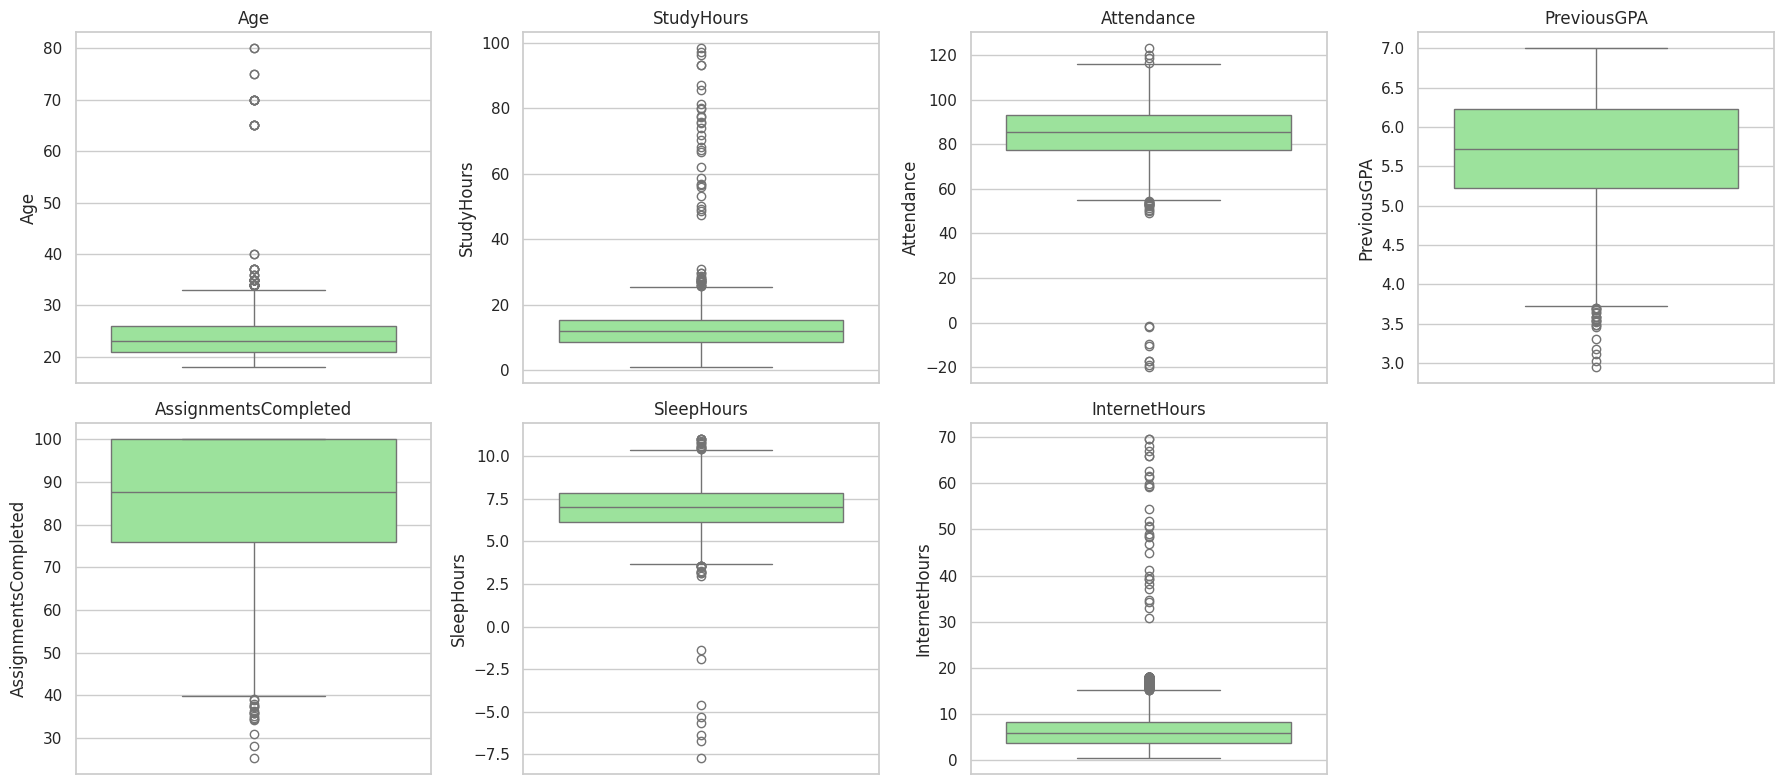

In [ ]:
revision_atipicos = ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)

axes[7].set_visible(False)
plt.tight_layout()
plt.show()

**Análisis 1.5: Valores Atípicos**
* **Variables afectadas:** Los diagramas de caja muestran valores fuera de los rangos intercuartílicos principalmente en `StudyHours`, `InternetHours` y `AssignmentsCompleted`. La cantidad exacta varía, pero representan proporciones menores en los extremos superior e inferior.
* **Diferencia entre valor extremo e inválido:** Un estudiante que reporta -20 en `Attendance` es un **valor inválido** (imposible en la realidad, tratado en la fase 1.4). Un estudiante que reporta estudiar 40 horas a la semana es un **valor extremo (outlier)**; es un número inusual, pero físicamente posible.
* **Estrategia de Tratamiento y Justificación:** Dado que estos valores extremos representan el comportamiento genuino de ciertos estudiantes (minorías), eliminarlos causaría pérdida de representatividad. Por lo tanto, se mantendrán en el dataset. Para mitigar su impacto en el modelo de Machine Learning, justificamos el uso de la estandarización mediante `StandardScaler` (o `RobustScaler`) aplicado dentro del Pipeline numérico.

## 2. Análisis Exploratorio de Datos (EDA)


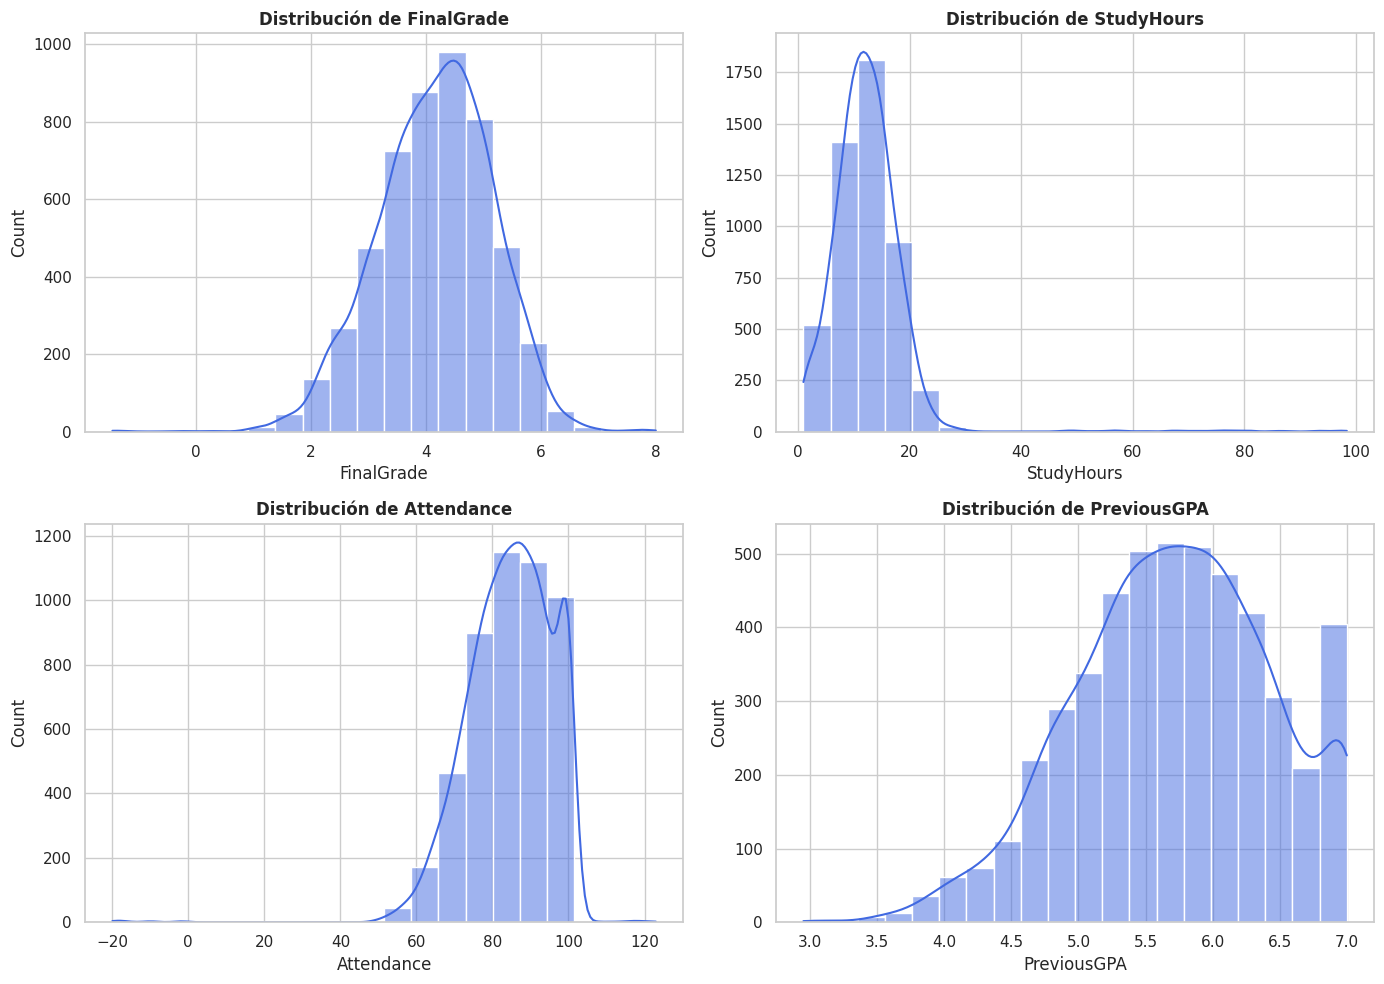

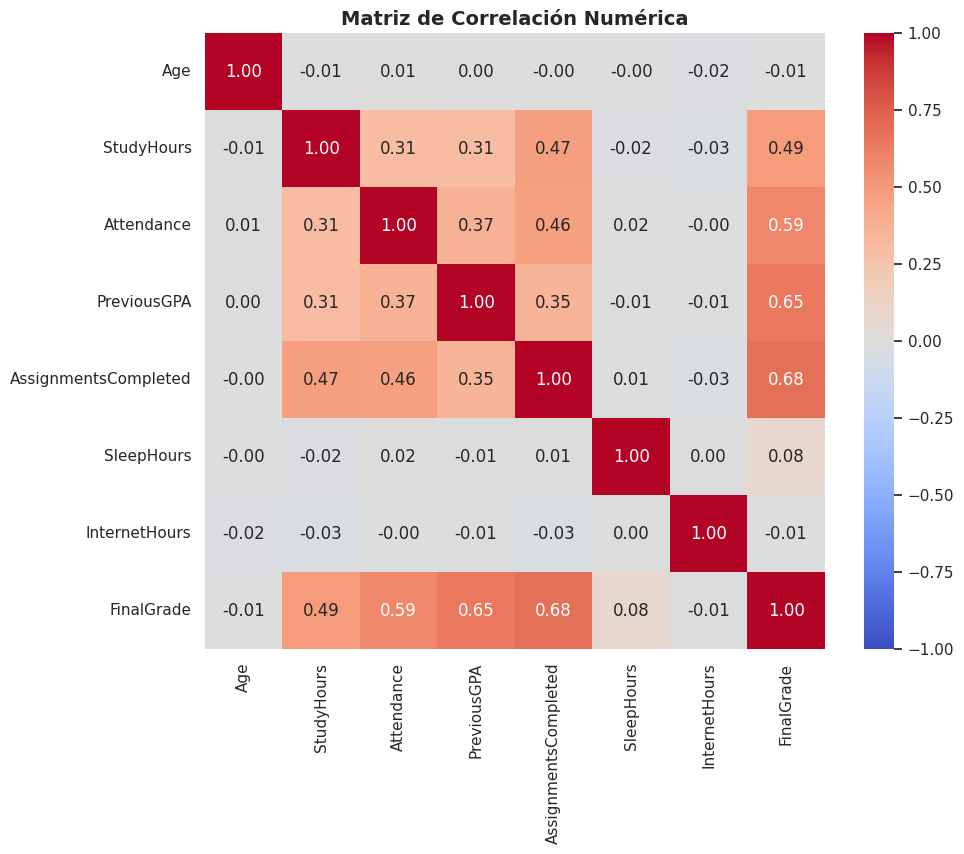

In [ ]:
# Corrección temporal de texto para el EDA
df_eda = df.copy()
for col in ['Scholarship', 'Program']:
    df_eda[col] = df_eda[col].str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.strip()

# 1. Distribución de Variables
variables_histograma = ['FinalGrade', 'StudyHours', 'Attendance', 'PreviousGPA']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variables_histograma):
    sns.histplot(df_eda[col], bins=20, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Matriz de Correlación
num_cols = df_eda.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación Numérica', fontsize=14, fontweight='bold')
plt.show()

**Interpretación de Visualizaciones (EDA):**
* **Distribución de Variables Numéricas (Histogramas):** La variable objetivo `FinalGrade` presenta una distribución cercana a la campana de Gauss (distribución normal). Por su parte, `StudyHours` muestra un marcado sesgo positivo (cola hacia la derecha, la mayoría estudia pocas horas) y `Attendance` un sesgo negativo (cola hacia la izquierda, la mayoría asiste frecuentemente).
* **Matriz de Correlación (Heatmap):** Las relaciones lineales más fuertes y significativas con respecto a la calificación final (`FinalGrade`) son `AssignmentsCompleted` (correlación de 0.68) y `PreviousGPA` (correlación de 0.65). Estas dos variables serán predictores fundamentales en el modelo.

### Preguntas de Investigación

--- Pregunta 1: Becas ---


,FinalGrade
Scholarship,
no,4.072793
si,4.369466


Diferencia: 0.30 puntos a favor de los estudiantes con beca.

--- Pregunta 2: Programas Académicos ---


,FinalGrade
Program,
ingenieria informatica,4.231643
administracion,4.214478
ingenieria industrial,4.200809
ingenieria civil,4.105638
contador auditor,4.045193


Diferencia entre el programa con mayor y menor promedio: 0.19 puntos.

--- Pregunta 3 y 4: Relaciones ---
Correlación StudyHours vs FinalGrade: 0.49
Correlación Attendance vs FinalGrade: 0.59



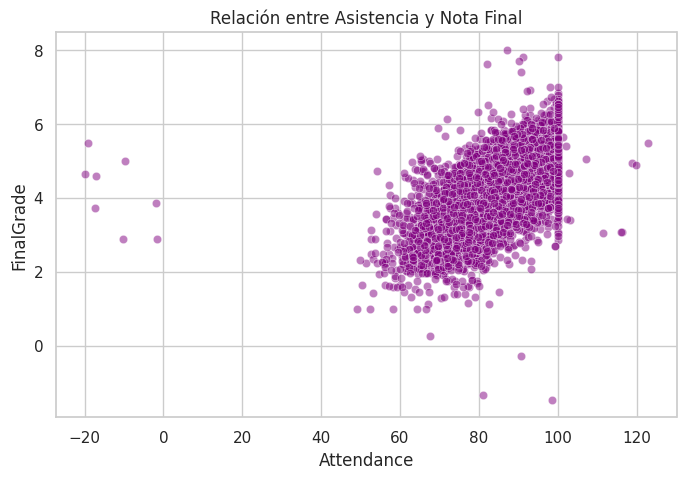

In [ ]:
print("--- Pregunta 1: Becas ---")
becas_mean = df_eda.groupby('Scholarship')['FinalGrade'].mean()
display(becas_mean)
if 'si' in becas_mean and 'no' in becas_mean:
    diff_becas = abs(becas_mean['si'] - becas_mean['no'])
    print(f"Diferencia: {diff_becas:.2f} puntos a favor de los estudiantes {'con' if becas_mean['si'] > becas_mean['no'] else 'sin'} beca.\n")

print("--- Pregunta 2: Programas Académicos ---")
prog_mean = df_eda.groupby('Program')['FinalGrade'].mean().sort_values(ascending=False)
display(prog_mean)
diff_prog = prog_mean.max() - prog_mean.min()
print(f"Diferencia entre el programa con mayor y menor promedio: {diff_prog:.2f} puntos.\n")

print("--- Pregunta 3 y 4: Relaciones ---")
corr_study = df_eda['StudyHours'].corr(df_eda['FinalGrade'])
corr_att = df_eda['Attendance'].corr(df_eda['FinalGrade'])
print(f"Correlación StudyHours vs FinalGrade: {corr_study:.2f}")
print(f"Correlación Attendance vs FinalGrade: {corr_att:.2f}\n")

# Gráfico para Pregunta 4
plt.figure(figsize=(8,5))
sns.scatterplot(x='Attendance', y='FinalGrade', data=df_eda, alpha=0.5, color='purple')
plt.title("Relación entre Asistencia y Nota Final")
plt.show()

**Interpretación y Respuestas:**

* **Pregunta 1:** Sí, existe diferencia. Los estudiantes con beca presentan un mejor rendimiento promedio en comparación con los que no poseen beca.
* **Pregunta 2:** El programa con mayor promedio es Ingeniería Informática (4.23) y el de menor promedio es Contador Auditor (4.05), con una diferencia de 0.19 puntos — una brecha modesta entre programas.
* **Pregunta 3:** Existe una correlación positiva moderada (`~0.49`) entre las horas de estudio (`StudyHours`) y la calificación final. A mayor cantidad de horas, el rendimiento tiende a subir.
* **Pregunta 4:** Existe una relación positiva (`~0.59`) entre la asistencia (`Attendance`) y la calificación final. El gráfico de dispersión confirma que las notas más altas se concentran fuertemente en el cuadrante de alta asistencia (sobre el 80%).

**Tres conclusiones generales del EDA:**
1. Las variables académicas de disciplina (`AssignmentsCompleted`, `PreviousGPA` y `Attendance`) son los predictores lineales más fuertes del rendimiento, superando a variables de estilo de vida como `InternetHours`.
2. La limpieza de los datos categóricos es vital: sin estandarizar el texto, el EDA divide erróneamente un mismo programa o estado de beca en múltiples grupos falsos.
3. La variable objetivo `FinalGrade` sigue una distribución normal ideal para algoritmos predictivos, pero presenta algunas calificaciones imposibles (negativas o cero) que deben ser imputadas antes del modelamiento.

## 3. Tratamiento de los datos

In [ ]:
# --- 3. TRATAMIENTO PREVIO ---
df_clean = df.copy()

# 3.1 Tratamiento de Registros Duplicados
df_clean = df_clean.drop_duplicates()

# 3.2 Tratamiento de Inconsistencias Estructurales (Categóricas)
# Normalizamos el texto (minúsculas, sin tildes, sin espacios extra)
# se aplica solo sobre los valores no nulos para no convertir NaN en el string "nan"
for col in ['Scholarship', 'Program']:
    mask = df_clean[col].notna()
    df_clean.loc[mask, col] = (
        df_clean.loc[mask, col]
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
        .str.strip()
    )

# 3.3 Tratamiento de Inconsistencias Lógicas (Numéricas)
# Convertimos los valores ilógicos a NaN para que el Pipeline los impute luego estadísticamente
df_clean.loc[(df_clean["Age"] <= 0) | (df_clean["Age"] > 100), "Age"] = np.nan
df_clean.loc[(df_clean["Attendance"] < 0) | (df_clean["Attendance"] > 100), "Attendance"] = np.nan
df_clean.loc[(df_clean["PreviousGPA"] < 1.0) | (df_clean["PreviousGPA"] > 10), "PreviousGPA"] = np.nan
df_clean.loc[(df_clean["StudyHours"] < 0) | (df_clean["StudyHours"] > 80), "StudyHours"] = np.nan
df_clean.loc[(df_clean["SleepHours"] < 0) | (df_clean["SleepHours"] > 24), "SleepHours"] = np.nan
df_clean.loc[(df_clean["InternetHours"] < 0) | (df_clean["InternetHours"] > 24), "InternetHours"] = np.nan
df_clean.loc[(df_clean["AssignmentsCompleted"] < 0) | (df_clean["AssignmentsCompleted"] > 100), "AssignmentsCompleted"] = np.nan

# 3.4 Tratamiento de la Variable Objetivo (Target)
# Eliminamos filas donde FinalGrade es ilógica o nula, ya que no se debe alterar la variable a predecir
df_clean = df_clean[(df_clean["FinalGrade"] >= 1.0) & (df_clean["FinalGrade"] <= 10)]
df_clean = df_clean.dropna(subset=['FinalGrade'])

# 3.5 Separación de Variables de Entrada (X) y Target (y)
X = df_clean.drop(columns=['StudentID', 'FinalGrade'])
y = df_clean['FinalGrade']

## 4. Implementación mediante Pipeline
A continuación, definimos el `ColumnTransformer` y los `Pipelines` para automatizar el tratamiento de nulos, la codificación de texto y el manejo del impacto de los valores atípicos mediante escalado.

In [ ]:
# --- 4. IMPLEMENTACIÓN CON PIPELINE ---

# 4.1 Identificación de columnas
cols_num = X.select_dtypes(include=[np.number]).columns.tolist()
cols_cat = X.select_dtypes(exclude=[np.number]).columns.tolist()

# 4.2 Definición de transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputa nulos e inconsistencias previas
    ('scaler', StandardScaler()) # Mitiga influencia de valores atípicos
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa nulos categóricos
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')) # Crea dummies
])

# 4.3 Ensamblaje del preprocesador
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, cols_num),
    ('cat', categorical_transformer, cols_cat)
])

# 4.4 Ajuste y transformación de los datos de entrada
X_transformed = preprocessor.fit_transform(X)

# 4.5 Recuperar los nombres de las columnas
cat_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cols_cat)
all_features = cols_num + list(cat_features)

# 4.6 Reconstrucción del Dataset Final
df_final = pd.DataFrame(X_transformed, columns=all_features, index=X.index)

# Reintegramos la variable objetivo y el identificador
df_final['FinalGrade'] = y.values
df_final.insert(0, 'StudentID', df_clean['StudentID'].values)

## 5. Dataset Final y Evidencia

In [ ]:
# 1. Exportar el CSV
df_final.to_csv('rendimiento_academico_limpio.csv', index=False)
print("Archivo 'rendimiento_academico_limpio.csv' exportado exitosamente.\n")

# 2. Comprobación y Tabla Comparativa
final_shape = df_final.shape
final_nulos = df_final.isnull().sum().sum()
final_duplicados = df_final.duplicated().sum()

# Inconsistencias originales (escala 1-10, ver Metadata.md)
inconsistencias_originales = len(df[
    (df["Age"] <= 0) | (df["Age"] > 100) |
    (df["Attendance"] < 0) | (df["Attendance"] > 100) |
    (df["PreviousGPA"] < 1.0) | (df["PreviousGPA"] > 10.0) |
    (df["FinalGrade"] < 1.0) | (df["FinalGrade"] > 10.0)
])

# Inconsistencias finales: se calculan sobre df_clean (antes de escalar),
# que es donde Age, Attendance, PreviousGPA y FinalGrade siguen en su escala real
inconsistencias_finales = len(df_clean[
    (df_clean["Age"] <= 0) | (df_clean["Age"] > 100) |
    (df_clean["Attendance"] < 0) | (df_clean["Attendance"] > 100) |
    (df_clean["PreviousGPA"] < 1.0) | (df_clean["PreviousGPA"] > 10.0) |
    (df_clean["FinalGrade"] < 1.0) | (df_clean["FinalGrade"] > 10.0)
])

# Construcción exacta de la tabla exigida en la rúbrica
comparacion = pd.DataFrame({
    'Indicador': [
        'Cantidad de registros',
        'Cantidad de variables',
        'Valores faltantes',
        'Registros duplicados',
        'Inconsistencias',
        'Outliers tratados'
    ],
    'Dataset original': [
        original_shape[0],
        original_shape[1],
        original_nulos,
        original_duplicados,
        inconsistencias_originales,
        "No"
    ],
    'Dataset tratado': [
        final_shape[0],
        final_shape[1],
        final_nulos,
        final_duplicados,
        inconsistencias_finales,
        "Sí (Escalado Robusto/Estándar)"
    ]
})

print("--- Comparación de Calidad de Datos (Original vs Tratado) ---")
display(comparacion)

Archivo 'rendimiento_academico_limpio.csv' exportado exitosamente.

--- Comparación de Calidad de Datos (Original vs Tratado) ---


,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,14
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias,24,0
5,Outliers tratados,No,Sí (Escalado Robusto/Estándar)
